##  MPI ping-pong measuring message latency and bandwidth

In [1]:
n = 2 # number of processes
from ipyparallel import Cluster
import os
os.environ["OMPI_MCA_rmaps_base_oversubscribe"] = "1" # OpenMPI flag to oversubscribe in case we have less cpus than n
cluster = await Cluster(engines="mpi").start_and_connect(n=n, activate=True)

Starting 2 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:05<00:00,  2.77s/engine]


In [2]:
%%px
from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt

comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()

if size != 2:
    if rank == 0:
        print("This program requires exactly 2 processes")
    exit()

partner_rank = 1 - rank
message_sizes = [1, 10, 100, 1000, 10000, int(1e5), int(1e6), int(1e7), int(1e8)]  # bytes
niter = 1000

latencies = []
bandwidths = []

for size_bytes in message_sizes:
    # Create message
    msg = np.zeros(size_bytes, dtype='b')  # bytes array
    comm.Barrier()  # synchronize before timing
    start = MPI.Wtime()

    for _ in range(niter):
        if rank == 0:
            comm.Send([msg, MPI.BYTE], dest=partner_rank) # uppercase methods are used for buffer-like objects
            comm.Recv([msg, MPI.BYTE], source=partner_rank)
        else:
            comm.Recv([msg, MPI.BYTE], source=partner_rank)
            comm.Send([msg, MPI.BYTE], dest=partner_rank)

    end = MPI.Wtime()
    total_time = end - start
    avg_rtt = total_time / niter
    one_way_latency = avg_rtt / 2
    latencies.append(one_way_latency * 1e6)  # µs

    # Bandwidth = message size / one-way time
    bw = (size_bytes / one_way_latency) / 1e6  # MB/s
    bandwidths.append(bw)

    if rank == 0:
        print(f"Size: {size_bytes} B, latency: {one_way_latency*1e6:.2f} µs, bandwidth: {bw:.2f} MB/s")

[stdout:0] Size: 1 B, latency: 1.46 µs, bandwidth: 0.68 MB/s
Size: 10 B, latency: 1.49 µs, bandwidth: 6.69 MB/s
Size: 100 B, latency: 1.42 µs, bandwidth: 70.21 MB/s
Size: 1000 B, latency: 1.53 µs, bandwidth: 655.36 MB/s
Size: 10000 B, latency: 2.09 µs, bandwidth: 4786.73 MB/s
Size: 100000 B, latency: 4.53 µs, bandwidth: 22063.15 MB/s
Size: 1000000 B, latency: 23.16 µs, bandwidth: 43185.08 MB/s
Size: 10000000 B, latency: 152.72 µs, bandwidth: 65480.10 MB/s
Size: 100000000 B, latency: 4026.38 µs, bandwidth: 24836.19 MB/s
Size: 1000000000 B, latency: 55748.06 µs, bandwidth: 17937.84 MB/s


%px: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [01:58<00:00, 59.04s/tasks]


[output:0]

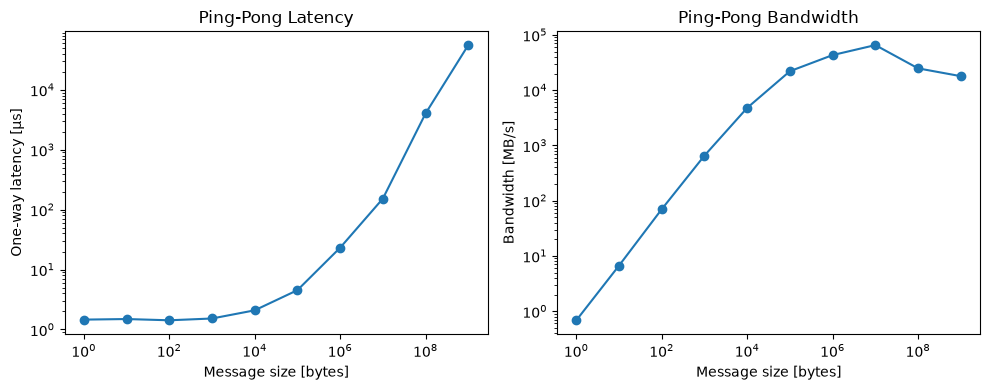

In [3]:
%%px
if rank == 0:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.loglog(message_sizes, latencies, 'o-')
    plt.xlabel("Message size [bytes]")
    plt.ylabel("One-way latency [µs]")
    plt.title("Ping-Pong Latency")

    plt.subplot(1,2,2)
    plt.loglog(message_sizes, bandwidths, 'o-')
    plt.xlabel("Message size [bytes]")
    plt.ylabel("Bandwidth [MB/s]")
    plt.title("Ping-Pong Bandwidth")

    plt.tight_layout()
    plt.show()